In [ ]:
import torch
import ollama
from PIL import Image
from matplotlib import pyplot as plt


In [ ]:
response = ollama.chat(
    model='qwen3.5:0.8b',
    messages=[{
        'role': 'user',
        'content': "describe this image",
        # 'content': 'Describe the image in natural, fluent English. Do NOT use labels like "Action", "Object", or bullet points. Write a normal sentence like a human would.',
        'images': ['../../example.jpg']
    }]
)

print(response)

In [ ]:
response["message"]["content"]

In [ ]:
# This code uses:
# @misc{qwen3technicalreport,
#       title={Qwen3 Technical Report}, 
#       author={Qwen Team},
#       year={2025},
#       eprint={2505.09388},
#       archivePrefix={arXiv},
#       primaryClass={cs.CL},
#       url={https://arxiv.org/abs/2505.09388}, 
# }

In [ ]:
from transformers import AutoModelForImageTextToText, AutoProcessor

# default: Load the model on the available device(s)
model = AutoModelForImageTextToText.from_pretrained(
    "Qwen/Qwen3-VL-235B-A22B-Instruct", dtype="auto", device_map="auto"
)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
# model = AutoModelForImageTextToText.from_pretrained(
#     "Qwen/Qwen3-VL-235B-A22B-Instruct",
#     dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
#     device_map="auto",
# )

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-235B-A22B-Instruct")

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Preparation for inference
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)

In [3]:
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

# default: Load the model on the available device(s)
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct", dtype="auto", device_map="auto"
)

# We recommend enabling flash_attention_2 for better acceleration and memory saving, especially in multi-image and video scenarios.
# model = Qwen3VLForConditionalGeneration.from_pretrained(
#     "Qwen/Qwen3-VL-8B-Instruct",
#     dtype=torch.bfloat16,
#     attn_implementation="flash_attention_2",
#     device_map="auto",
# )

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "https://qianwen-res.oss-cn-beijing.aliyuncs.com/Qwen-VL/assets/demo.jpeg",
            },
            {"type": "text", "text": "Describe this image."},
        ],
    }
]

# Preparation for inference
inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt"
)
inputs = inputs.to(model.device)

# Inference: Generation of the output
generated_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids_trimmed = [
    out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
output_text = processor.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)
print(output_text)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 7.22 GiB. GPU 0 has a total capacity of 10.90 GiB of which 6.83 GiB is free. Including non-PyTorch memory, this process has 4.07 GiB memory in use. Of the allocated memory 3.87 GiB is allocated by PyTorch, and 41.75 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
!pwd 

/home/gusloryst@GU.GU.SE/mgr/image_processing


In [3]:
response = ollama.chat(
    model='llama3.2-vision',
    messages=[{
        'role': 'user',
        'content': 'Describe the image in natural, fluent English. Do NOT use labels like "Action", "Object", or bullet points. Write a normal sentence like a human would.',
        'images': ['../../example.jpg']
    }]
)

print(response)


model='llama3.2-vision' created_at='2026-03-31T06:50:22.424628426Z' done=True done_reason='stop' total_duration=17490326107 load_duration=6466408133 prompt_eval_count=43 prompt_eval_duration=239932196 eval_count=140 eval_duration=4691930868 message=Message(role='assistant', content="The image shows a dog playing with a puzzle toy. The dog is lying on a grey blanket, with its front paws resting on a blue puzzle toy. The dog is brown and white, with a long, fluffy coat. It has its nose buried in the toy, which has six red and white compartments. The dog's ears are perked up, and its eyes are focused on the toy. The background is a plain grey wall, suggesting that the image was taken in a home or studio setting. The overall atmosphere of the image is one of fun and playfulness, as the dog is clearly enjoying itself as it tries to figure out how to get the treats out of the toy.", thinking=None, images=None, tool_name=None, tool_calls=None) logprobs=None


In [11]:
response["message"]["content"]

"The image shows a dog playing with a puzzle toy. The dog is lying on a grey blanket, with its front paws resting on a blue puzzle toy. The dog is brown and white, with a long, fluffy coat. It has its nose buried in the toy, which has six red and white compartments. The dog's ears are perked up, and its eyes are focused on the toy. The background is a plain grey wall, suggesting that the image was taken in a home or studio setting. The overall atmosphere of the image is one of fun and playfulness, as the dog is clearly enjoying itself as it tries to figure out how to get the treats out of the toy."

In [4]:
dir(response)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__class_getitem__',
 '__class_vars__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__fields__',
 '__fields_set__',
 '__format__',
 '__ge__',
 '__get_pydantic_core_schema__',
 '__get_pydantic_json_schema__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__pretty__',
 '__private_attributes__',
 '__pydantic_complete__',
 '__pydantic_computed_fields__',
 '__pydantic_core_schema__',
 '__pydantic_custom_init__',
 '__pydantic_decorators__',
 '__pydantic_extra__',
 '__pydantic_fields__',
 '__pydantic_fields_set__',
 '__pydantic_generic_metadata__',
 '__pydantic_init_subclass__',
 '__pydantic_on_complete__',
 '__pydantic_parent_namespace__',
 '__pydantic_post_init__',
 '__pydantic_private__',
 '__pydantic_root_mo

In [15]:
response.done

True

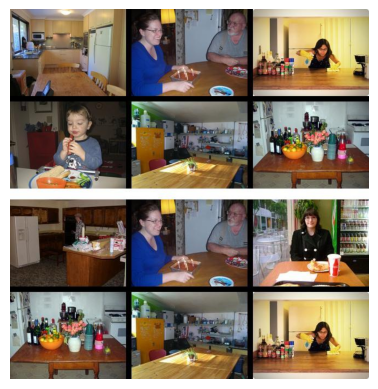

model='qwen3.5:0.8b' created_at='2026-03-20T13:55:16.591979841Z' done=True done_reason='stop' total_duration=452905187144 load_duration=5762576870 prompt_eval_count=534 prompt_eval_duration=163288162 eval_count=33140 eval_duration=300833888124 message=Message(role='assistant', content='Based on the standard layout for a photobook spread (often used to display multiple photographs from different pages of a book), here is an analysis comparing **Page A** (top half) and **Page B** (bottom half).\n\n### **Visual Analysis & Comparison**\n\n*   **Page A (Top Half):** Located on the left side.\n    *   **Contents:** Shows photos for **Page 1 (likely Page 1\'s Top Row)**.\n    *   Visible items include:\n        *   A **Kitchen counter**.\n        *   A woman wearing blue eating cake.\n        *   A man wearing grey holding a cake.\n    *   These appear to be close to the same people or setting, suggesting they might belong to the same couple taking photos together (a common feature of spreads

In [3]:
example = Image.open("PhotoBook/merged_images/2106_2_merged.jpg")
plt.imshow(example)
plt.axis('off')
plt.show()


response = ollama.chat(
    model='qwen3.5:0.8b',
    messages=[{
        'role': 'user',
        'content': 'You are given a photobook spread. The top half shows one page and the bottom half shows another page, separated by a white stripe.\nEach page contains 6 photos.\nTask:\n1. Compare the two pages.\n2. Count how many photos appear on both pages (the same or very similar).\n3. Describe the matching photos.\nAnswer clearly and step by step.',
        'images': ['PhotoBook/merged_images/2106_2_merged.jpg']
    }]
)

print(response)